In [ ]:
!pip install --upgrade chromadb opentelemetry-api opentelemetry-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opentelemetr

In [ ]:
#!pip install langchain --force-reinstall
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, unix_timestamp, hour, dayofweek, when
)
import time
import pandas as pd

In [ ]:
!pip install pypdf
from pypdf import PdfReader
import os
from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 5.6 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

#default
splitter_1000 = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)


Task 1.1

In [ ]:
spark = SparkSession.builder \
    .appName('NYC Yellow Trip Data') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

In [ ]:
!mkdir -p /content/data
!wget -O /content/data/yellow_tripdata_2024-01.parquet https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
#because i doing this in colab and a programmatic download works a lil differently here

--2026-04-03 04:47:07--  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 54.230.248.64, 54.230.248.73, 54.230.248.205, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|54.230.248.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49961641 (48M) [binary/octet-stream]
Saving to: ‘/content/data/yellow_tripdata_2024-01.parquet’

/content/data/yello 100%[===================>]  47.65M  61.2MB/s    in 0.8s    

2026-04-03 04:47:08 (61.2 MB/s) - ‘/content/data/yellow_tripdata_2024-01.parquet’ saved [49961641/49961641]



In [ ]:
file_path = "/content/data/yellow_tripdata_2024-01.parquet"
df = spark.read.parquet(file_path)

In [ ]:
df.printSchema()
row_count = df.count()
partition_count = df.rdd.getNumPartitions()

print("Row count: ", row_count)
print("Partition count: ", partition_count)

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

Row count:  2964624
Partition count:  2


In [ ]:
start = time.time()
df = spark.read.parquet(file_path)
df.count()
spark_time = time.time() - start
print("Spark Load Time: ", spark_time)

Spark Load Time:  1.9904026985168457


In [ ]:
start = time.time()
pd_df = pd.read_parquet(file_path)
pd_time = time.time() - start
print("Pandas Load Time: ", pd_time)

Pandas Load Time:  3.3336682319641113


In [ ]:
if spark_time < pd_time:
    print("Spark is faster")
else:
    print("Pandas is faster")

Spark is faster


Task 1.2

In [ ]:
df_clean = df
critical_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "fare_amount"
]

In [ ]:
before_null = df_clean.count()
df_clean = df_clean.dropna(subset=critical_columns)
after_null = df_clean.count()
print("Null rows removed: ", before_null - after_null)

Null rows removed:  0


In [ ]:
before_invalid = df_clean.count()
df_clean = df_clean.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") >= 0) &
    (col("fare_amount") <= 500) &
    (col("tpep_dropoff_datetime") > col("tpep_pickup_datetime"))
)

after_invalid = df_clean.count()
print("Invalid Trip rows removed: ", before_invalid - after_invalid)

Invalid Trip rows removed:  94578


In [ ]:
df_clean = df_clean.withColumn(
    "trip_duration_minutes",
    (unix_timestamp("tpep_dropoff_datetime") -
     unix_timestamp("tpep_pickup_datetime")) / 60
)

In [ ]:
df_clean = df_clean.withColumn(
    "trip_speed_mph",
    when(col("trip_duration_minutes") > 0,
         col("trip_distance") / (col("trip_duration_minutes") / 60)
    ).otherwise(0)
)

In [ ]:
df_clean = df_clean.withColumn(
    "pickup_hour",
    hour("tpep_pickup_datetime")
)

df_clean = df_clean.withColumn(
    "pickup_day_of_week",
    dayofweek("tpep_pickup_datetime")
)

In [ ]:
#tip percentage
df_clean = df_clean.withColumn(
    "tip_percentage",
    when(col("fare_amount") > 0,
         (col("tip_amount") / col("fare_amount")) * 100
    ).otherwise(0)
)

In [ ]:
final_count = df_clean.count()
print("Cleaned Dataset Rows: ", final_count)

Cleaned Dataset Rows:  2870046


Task 1.3

In [ ]:
df_clean.createOrReplaceTempView("taxi_trips")

In [ ]:
query1 = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    AVG(fare_amount) AS avg_fare,
    AVG(tip_percentage) AS avg_tip_percentage
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY trip_count DESC
LIMIT 10
""")

query1.show()

+-----------+----------+------------------+------------------+
|pickup_hour|trip_count|          avg_fare|avg_tip_percentage|
+-----------+----------+------------------+------------------+
|         18|    206281|17.013177413334063| 22.78098951455497|
|         17|    200310| 18.11784723678297|22.339957734185298|
|         16|    184968| 19.45697407119098|21.834890524370486|
|         15|    184004| 19.11065754005336|  19.7974469820577|
|         19|    178810| 17.62666869861882|22.856272151997278|
|         14|    178026| 19.27061204543176|19.795226370707898|
|         13|    165355|18.418028242266633|19.782433340168616|
|         12|    159912|17.795682125169133|19.739223575366942|
|         21|    155910|18.292533897761444| 21.87784385541404|
|         20|    155559|18.050304128979953|  22.1687056636625|
+-----------+----------+------------------+------------------+



The busiest pickup hour is hour 18. Low fare but on the higher end of average for tipping.

In [ ]:
query2 = spark.sql("""
SELECT
    pickup_day_of_week,
    AVG(trip_speed_mph) AS avg_speed,
    AVG(trip_distance) AS avg_distance,
    AVG(trip_duration_minutes) AS avg_duration
FROM taxi_trips
GROUP BY pickup_day_of_week
ORDER BY avg_speed DESC
LIMIT 1
""")

query2.show()

+------------------+-----------------+----------------+-----------------+
|pickup_day_of_week|        avg_speed|    avg_distance|     avg_duration|
+------------------+-----------------+----------------+-----------------+
|                 3|17.45554799703189|4.24525863604385|16.17535269226049|
+------------------+-----------------+----------------+-----------------+



In [ ]:
query3 = spark.sql("""
SELECT *
FROM (
    SELECT
        pickup_day_of_week,
        PULocationID,
        SUM(fare_amount) AS total_revenue,
        RANK() OVER (
            PARTITION BY pickup_day_of_week
            ORDER BY SUM(fare_amount) DESC
        ) AS rank
    FROM taxi_trips
    GROUP BY pickup_day_of_week, PULocationID
) ranked
WHERE rank <= 5
""")

query3.show()

+------------------+------------+------------------+----+
|pickup_day_of_week|PULocationID|     total_revenue|rank|
+------------------+------------+------------------+----+
|                 1|         132|1221515.0499999998|   1|
|                 1|         138|487599.09999999875|   2|
|                 1|         230|234662.64000000016|   3|
|                 1|         186| 179524.2699999999|   4|
|                 1|          79|173513.36000000013|   5|
|                 2|         132| 1593427.760000003|   1|
|                 2|         138| 648123.5200000003|   2|
|                 2|         161| 299014.9200000002|   3|
|                 2|         186|236408.26000000077|   4|
|                 2|         236|236288.67000000092|   5|
|                 3|         132|1393573.0899999975|   1|
|                 3|         138| 597059.8199999982|   2|
|                 3|         161| 398153.6599999998|   3|
|                 3|         236| 307750.2299999984|   4|
|             

In [ ]:
query4 = spark.sql("""
SELECT
    pickup_hour,
    COUNT(*) AS trip_count,
    SUM(COUNT(*)) OVER (
        ORDER BY pickup_hour
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_trips
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY pickup_hour
""")

query4.show()

+-----------+----------+----------------+
|pickup_hour|trip_count|cumulative_trips|
+-----------+----------+----------------+
|          0|     75247|           75247|
|          1|     50490|          125737|
|          2|     34976|          160713|
|          3|     22947|          183660|
|          4|     15284|          198944|
|          5|     17495|          216439|
|          6|     39415|          255854|
|          7|     80870|          336724|
|          8|    113506|          450230|
|          9|    125619|          575849|
|         10|    135425|          711274|
|         11|    146754|          858028|
|         12|    159912|         1017940|
|         13|    165355|         1183295|
|         14|    178026|         1361321|
|         15|    184004|         1545325|
|         16|    184968|         1730293|
|         17|    200310|         1930603|
|         18|    206281|         2136884|
|         19|    178810|         2315694|
+-----------+----------+----------

In [ ]:
#i hope this dont break the guidelinesz
total_trips = df_clean.count()

query4_with_percentage = spark.sql(f"""
SELECT *,
       cumulative_trips / {total_trips} * 100 AS cumulative_percentage
FROM (
    SELECT
        pickup_hour,
        COUNT(*) AS trip_count,
        SUM(COUNT(*)) OVER (
            ORDER BY pickup_hour
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) AS cumulative_trips
    FROM taxi_trips
    GROUP BY pickup_hour
)
ORDER BY pickup_hour
""")

query4_with_percentage.show()

+-----------+----------+----------------+---------------------+
|pickup_hour|trip_count|cumulative_trips|cumulative_percentage|
+-----------+----------+----------------+---------------------+
|          0|     75247|           75247|     2.62180466793912|
|          1|     50490|          125737|    4.381009921095341|
|          2|     34976|          160713|   5.5996663468111665|
|          3|     22947|          183660|    6.399200570304448|
|          4|     15284|          198944|    6.931735588906937|
|          5|     17495|          216439|    7.541307700294698|
|          6|     39415|          255854|    8.914630636582132|
|          7|     80870|          336724|    11.73235550928452|
|          8|    113506|          450230|    15.68720501343881|
|          9|    125619|          575849|   20.064103502173833|
|         10|    135425|          711274|    24.78266898858067|
|         11|    146754|          858028|   29.895966824225116|
|         12|    159912|         1017940

In [ ]:
query5 = spark.sql("""
SELECT
    CASE
        WHEN trip_distance < 2 THEN 'Short (<2 miles)'
        WHEN trip_distance BETWEEN 2 AND 10 THEN 'Medium (2–10 miles)'
        ELSE 'Long (>10 miles)'
    END AS trip_category,
    AVG(fare_amount) AS avg_fare,
    AVG(trip_distance) AS avg_distance,
    AVG(tip_percentage) AS avg_tip_percentage
FROM taxi_trips
GROUP BY trip_category
""")

query5.show()

+-------------------+------------------+------------------+------------------+
|      trip_category|          avg_fare|      avg_distance|avg_tip_percentage|
+-------------------+------------------+------------------+------------------+
|   Short (<2 miles)| 9.911671764779602|1.1298230131060143| 23.06891607944474|
|   Long (>10 miles)| 64.64825875045544|21.699975430303088| 21.92859985476962|
|Medium (2–10 miles)|22.175948975297146| 3.961502662254225|18.570150930713844|
+-------------------+------------------+------------------+------------------+



Task 1.4

In [ ]:
start = time.time()

df_clean.groupBy("pickup_hour").count().show()

time_no_cache = time.time() - start
print("Time without cache:", time_no_cache)

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         12|159912|
|         22|138245|
|          1| 50490|
|         13|165355|
|          6| 39415|
|         16|184968|
|          3| 22947|
|         20|155559|
|          5| 17495|
|         19|178810|
|         15|184004|
|          9|125619|
|         17|200310|
|          4| 15284|
|          8|113506|
|         23|104638|
|          7| 80870|
|         10|135425|
|         21|155910|
|         11|146754|
+-----------+------+
only showing top 20 rows
Time without cache: 1.775296926498413


In [ ]:
df_clean.cache()
df_clean.count()

2870046

In [ ]:
start = time.time()

df_clean.groupBy("pickup_hour").count().show()

time_cache = time.time() - start
print("Time with cache:", time_cache)

+-----------+------+
|pickup_hour| count|
+-----------+------+
|         12|159912|
|         22|138245|
|          1| 50490|
|         13|165355|
|          6| 39415|
|         16|184968|
|          3| 22947|
|         20|155559|
|          5| 17495|
|         19|178810|
|         15|184004|
|          9|125619|
|         17|200310|
|          4| 15284|
|          8|113506|
|         23|104638|
|          7| 80870|
|         10|135425|
|         21|155910|
|         11|146754|
+-----------+------+
only showing top 20 rows
Time with cache: 1.4082629680633545


In [ ]:
output_path = "/content/taxi_partitioned"

df_clean.write \
    .mode("overwrite") \
    .partitionBy("pickup_hour") \
    .parquet(output_path)

In [ ]:
df_partition = spark.read.parquet(output_path)

df_hour_17 = df_partition.filter("pickup_hour = 17")

df_hour_17.show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+---------------------+------------------+------------------+------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|trip_duration_minutes|    trip_speed_mph|pickup_day_of_week|    tip_percentage|pickup_hour|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------

In [ ]:
df_hour_17.explain()

== Physical Plan ==
*(1) ColumnarToRow
+- FileScan parquet [VendorID#2353,tpep_pickup_datetime#2354,tpep_dropoff_datetime#2355,passenger_count#2356L,trip_distance#2357,RatecodeID#2358L,store_and_fwd_flag#2359,PULocationID#2360,DOLocationID#2361,payment_type#2362L,fare_amount#2363,extra#2364,mta_tax#2365,tip_amount#2366,tolls_amount#2367,improvement_surcharge#2368,total_amount#2369,congestion_surcharge#2370,Airport_fee#2371,trip_duration_minutes#2372,trip_speed_mph#2373,pickup_day_of_week#2374,tip_percentage#2375,pickup_hour#2376] Batched: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[file:/content/taxi_partitioned], PartitionFilters: [isnotnull(pickup_hour#2376), (pickup_hour#2376 = 17)], PushedFilters: [], ReadSchema: struct<VendorID:int,tpep_pickup_datetime:timestamp_ntz,tpep_dropoff_datetime:timestamp_ntz,passen...




Scan is there, evident as the attribites are read (scanned) and output.

Filter because this query is specifically about a specific pickup hour, 17 in this case.

In [ ]:
query1.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=10, orderBy=[trip_count#210L DESC NULLS LAST], output=[pickup_hour#179,trip_count#210L,avg_fare#211,avg_tip_percentage#212])
   +- HashAggregate(keys=[pickup_hour#179], functions=[count(1), avg(fare_amount#52), avg(tip_percentage#181)])
      +- Exchange hashpartitioning(pickup_hour#179, 200), ENSURE_REQUIREMENTS, [plan_id=1304]
         +- HashAggregate(keys=[pickup_hour#179], functions=[partial_count(1), partial_avg(fare_amount#52), partial_avg(tip_percentage#181)])
            +- InMemoryTableScan [fare_amount#52, pickup_hour#179, tip_percentage#181]
                  +- InMemoryRelation [VendorID#42, tpep_pickup_datetime#43, tpep_dropoff_datetime#44, passenger_count#45L, trip_distance#46, RatecodeID#47L, store_and_fwd_flag#48, PULocationID#49, DOLocationID#50, payment_type#51L, fare_amount#52, extra#53, mta_tax#54, tip_amount#55, tolls_amount#56, improvement_surcharge#57, total_amount#58, congest

Part 2: RAG

In [ ]:
os.listdir('/content/drive/MyDrive/docs')

['ConnectedNYC.pdf',
 'BridgesandTunnelsReport.pdf',
 'TaxiPooling.pdf',
 '2024AnnualReport.pdf',
 '2023AnnualReport.pdf',
 'RevisedExpenseModel.pdf',
 'ImprovementFundsReport.pdf']

In [ ]:
os.makedirs("docs", exist_ok=True)

In [ ]:
docs_path = "/content/drive/MyDrive/docs"

total_pages = 0
total_characters = 0

documents = []

for file in os.listdir(docs_path):
    if file.endswith(".pdf"):
        reader = PdfReader(os.path.join(docs_path, file))

        num_pages = len(reader.pages)
        total_pages += num_pages

        text = ""

        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text

        total_characters += len(text)

        documents.append({
            "file": file,
            "pages": num_pages,
            "characters": len(text),
            "text": text
        })

print("Total Pages:", total_pages)
print("Total Characters:", total_characters)

Total Pages: 257
Total Characters: 602642


In [ ]:
!pip install chromadb sentence-transformers matplotlib
splitter_1000 = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [ ]:
chunks_1000 = []

for doc in documents:
    split_texts = splitter_1000.split_text(doc["text"])

    for chunk in split_texts:
        chunks_1000.append({
            "text": chunk,
            "source": doc["file"],
            "page": doc["pages"]
        })

print("Total chunks (1000):", len(chunks_1000))

Total chunks (1000): 764


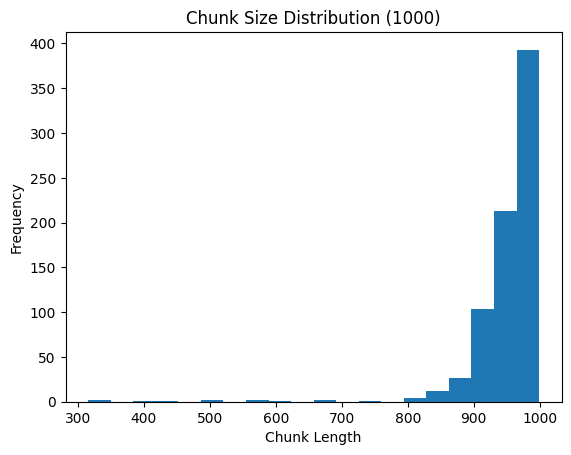

In [ ]:
import matplotlib.pyplot as plt

chunk_lengths = [len(c["text"]) for c in chunks_1000]

plt.hist(chunk_lengths, bins=20)
plt.title("Chunk Size Distribution (1000)")
plt.xlabel("Chunk Length")
plt.ylabel("Frequency")
plt.show()

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

texts_1000 = [c["text"] for c in chunks_1000]

embeddings_1000 = model.encode(texts_1000, show_progress_bar=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

In [ ]:
import chromadb

client = chromadb.Client()

#get or create cuz i all the rerunning giving me errors that it made already
collection_1000 = client.get_or_create_collection(name="chunks_1000")

for i, chunk in enumerate(chunks_1000):
    collection_1000.add(
        documents=[chunk["text"]],
        embeddings=[embeddings_1000[i]],
        metadatas=[
            {
                "source": chunk["source"],
                "page": chunk["page"]
            }
        ],
        ids=[str(i)]
    )

print("Stored 1000-size chunks in ChromaDB")

Stored 1000-size chunks in ChromaDB


In [ ]:
#a function cuz im too lazy to do three of these
def build_collection(chunk_size):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=200
    )

    chunks = []

    for doc in documents:
        split_texts = splitter.split_text(doc["text"])

        for chunk in split_texts:
            chunks.append({
                "text": chunk,
                "source": doc["file"],
                "page": doc["pages"]
            })

    texts = [c["text"] for c in chunks]

    embeddings = model.encode(texts, show_progress_bar=True)

    collection = client.create_collection(name=f"chunks_{chunk_size}")

    for i, chunk in enumerate(chunks):
        collection.add(
            documents=[chunk["text"]],
            embeddings=[embeddings[i]],
            metadatas=[{
                "source": chunk["source"],
                "page": chunk["page"]
            }],
            ids=[str(i)]
        )

    return collection

In [ ]:
collection_500 = build_collection(500)
collection_1000 = collection_1000  #already built
collection_2000 = build_collection(2000)

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [ ]:
queries = [
    "What are NYC taxi fare regulations?",
    "What policies govern driver behavior?",
    "How is tipping handled in taxi services?"
]

def test_query(collection, query):
    results = collection.query(
        query_texts=[query],
        n_results=3
    )
    return results["documents"][0]

In [ ]:
for q in queries:
    print("\n==============================")
    print("QUERY:", q)

    print("\n--- Chunk Size 500 ---")
    print(test_query(collection_500, q))

    print("\n--- Chunk Size 1000 ---")
    print(test_query(collection_1000, q))

    print("\n--- Chunk Size 2000 ---")
    print(test_query(collection_2000, q))


QUERY: What are NYC taxi fare regulations?

--- Chunk Size 500 ---


/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:00<00:00, 99.8MiB/s]


['accessible taxicab for a pick-up anywhere in the five boroughs. Customers may contact 311, \nuse a smartphone app, or call the dispatcher directly to request an accessible yellow or green \ntaxicab. Customers pay the metered taxi fare and there is no additional charge for the service. \nThe program was launched in September 2012 and served only Manhattan. In January 2018, \nthe program expanded to serve all five boroughs. Funds from the surcharge have covered the', 'expanding the earning potential of taxicab drivers. The ability to offer up-front pricing to customers is a key factor in the growth of the app-based FHV \nsector in New York City and around the world.  Passengers can still hail a taxicab in the street and pay the metered fare. \n \n100 Percent Wheelchair Accessible Taxi Vehicles  \nIn compliance with a federal court order dated August 28, 2024 in The Taxis for All Campaign, et al v. TLC, et al, TLC adopted rules that require that', '3Dept. of Mathematics, Cornell Univers

The experiment compared chunk sizes of 500, 1000, and 2000 characters. The 500-size chunks produced more precise but sometimes incomplete results due to limited context. The 2000-size chunks contained more context but often included irrelevant information, reducing retrieval accuracy. The 1000-size chunks provided the best balance between context and precision, consistently retrieving the most relevant and complete information across the test queries.

Task 2.3

In [ ]:
def retrieve(query, collection, k=3):
    results = collection.query(
        query_texts=[query],
        n_results=k
    )

    documents = results["documents"][0]
    metadata = results["metadatas"][0]

    return documents, metadata

In [ ]:
def build_prompt(query, contexts, metadata):
    context_text = ""

    for i, (ctx, meta) in enumerate(zip(contexts, metadata)):
        context_text += f"""
        [Source {i+1}]
        Document: {meta['source']}
        Page: {meta['page']}
        Content: {ctx}
        """

    prompt = f"""
You are an AI assistant answering questions about transportation policy.

IMPORTANT:
- Answer ONLY using the context provided below
- Do NOT use outside knowledge
- If the answer is not in the context, say "I don't know"
- Cite sources like (Source 1), (Source 2)

CONTEXT:
{context_text}

QUESTION:
{query}

ANSWER:
"""
    return prompt

In [ ]:
!pip install transformers

In [ ]:
from transformers import pipeline

generator = pipeline("text-generation", model="google/flan-t5-base")

def generate_answer(prompt):
    response = generator(prompt, max_length=512, do_sample=False)
    return response[0]["generated_text"]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

In [ ]:
def rag_pipeline(query, collection):
    contexts, metadata = retrieve(query, collection)

    prompt = build_prompt(query, contexts, metadata)

    answer = generate_answer(prompt)

    return {
        "question": query,
        "answer": answer,
        "contexts": contexts,
        "sources": metadata
    }

In [ ]:
questions = [
    "What are the rules for taxi fares in NYC?",
    "What regulations apply to taxi drivers?",
    "What safety policies are mentioned for transportation?",
    "How does tipping work in taxi services?",
    "What policies exist for ride-sharing or surge pricing?"
]

In [ ]:
for q in questions:
    result = rag_pipeline(q, collection_1000)

    print("\n==============================")
    print("QUESTION:", result["question"])

    print("\nANSWER:\n", result["answer"])

    print("\nSOURCES:")
    for s in result["sources"]:
        print(f"- {s['source']} (Page {s['page']})")

    print("\nCONTEXT SNIPPETS:")
    for c in result["contexts"]:
        print("-", c[:200], "...")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



QUESTION: What are the rules for taxi fares in NYC?

ANSWER:
 
You are an AI assistant answering questions about transportation policy.

IMPORTANT:
- Answer ONLY using the context provided below
- Do NOT use outside knowledge
- If the answer is not in the context, say "I don't know"
- Cite sources like (Source 1), (Source 2)

CONTEXT:

        [Source 1]
        Document: TaxiPooling.pdf
        Page: 32
        Content: Taxi pooling in New Y ork City: a network-based approach
to social sharing problems
Paolo Santi1,2, Giovanni Resta1, Michael Szell2, Stanislav Sobolevsky2, Steven Strogatz3 &
Carlo Ratti2
1Istituto di Informatica e Telematica del CNR, Pisa, Italy
2Senseable City Laboratory, MIT, Cambridge, MA, USA
3Dept. of Mathematics, Cornell University, Ithaca, NY , USA
Taxi services are a vital part of urban transportation, and a major contributor to trafﬁc con-
gestion and air pollution causing substantial adverse effects on human health 1, 2. Sharing
taxi trips is a possible way

Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



QUESTION: What regulations apply to taxi drivers?

ANSWER:
 
You are an AI assistant answering questions about transportation policy.

IMPORTANT:
- Answer ONLY using the context provided below
- Do NOT use outside knowledge
- If the answer is not in the context, say "I don't know"
- Cite sources like (Source 1), (Source 2)

CONTEXT:

        [Source 1]
        Document: TaxiPooling.pdf
        Page: 32
        Content: In this supplementary information we present the detailed methods, including the handling of
the data set, the formal derivation of the network-based approach used to quantify the beneﬁts
of a shared taxi system, and essential extended details of the analysis.
Data set and pre-processing
The data set contains origin-destination data of all 172 million trips with passengers of all
13,586 taxicabs in New Y ork during the calendar year of 2011. Each vehicle is associated with
a license, a so-called medallion, which is synonymously used as a name for the vehicles. These
med

Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



QUESTION: What safety policies are mentioned for transportation?

ANSWER:
 
You are an AI assistant answering questions about transportation policy.

IMPORTANT:
- Answer ONLY using the context provided below
- Do NOT use outside knowledge
- If the answer is not in the context, say "I don't know"
- Cite sources like (Source 1), (Source 2)

CONTEXT:

        [Source 1]
        Document: ConnectedNYC.pdf
        Page: 65
        Content: licensed, promoting safer practices for 
riders and reducing the risk of crashes. 
Commercial vehicles also play a significant role in road safety. NYC DOT is working 
to advance rules that mandate safer truck 
designs, to promote better visibility and 
smaller truck sizes to minimize risks 
to pedestrians and cyclists. For its own 
fleet, NYC DOT will incorporate the latest 
safety technologies, including intelligent 
speed assist, while seeking new funding 
opportunities that could help implement 
fleet-wide safety improvements. 
Enhance Vehicle Safety

Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



QUESTION: How does tipping work in taxi services?

ANSWER:
 
You are an AI assistant answering questions about transportation policy.

IMPORTANT:
- Answer ONLY using the context provided below
- Do NOT use outside knowledge
- If the answer is not in the context, say "I don't know"
- Cite sources like (Source 1), (Source 2)

CONTEXT:

        [Source 1]
        Document: TaxiPooling.pdf
        Page: 32
        Content: Taxi pooling in New Y ork City: a network-based approach
to social sharing problems
Paolo Santi1,2, Giovanni Resta1, Michael Szell2, Stanislav Sobolevsky2, Steven Strogatz3 &
Carlo Ratti2
1Istituto di Informatica e Telematica del CNR, Pisa, Italy
2Senseable City Laboratory, MIT, Cambridge, MA, USA
3Dept. of Mathematics, Cornell University, Ithaca, NY , USA
Taxi services are a vital part of urban transportation, and a major contributor to trafﬁc con-
gestion and air pollution causing substantial adverse effects on human health 1, 2. Sharing
taxi trips is a possible way o

Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



QUESTION: What policies exist for ride-sharing or surge pricing?

ANSWER:
 
You are an AI assistant answering questions about transportation policy.

IMPORTANT:
- Answer ONLY using the context provided below
- Do NOT use outside knowledge
- If the answer is not in the context, say "I don't know"
- Cite sources like (Source 1), (Source 2)

CONTEXT:

        [Source 1]
        Document: RevisedExpenseModel.pdf
        Page: 45
        Content: considerably more than the cost of owning. In part, this reflects the need for the renter 
to pay a combined 20.875 percent sales tax and a “registration rent,” and in part from 
the fact that business and individual owners renting out vehicles seek to make a profit, 
adding a cost on top of depreciation costs.
Despite the fact that there is a sizable 87,000-vehicle HV fleet, there are no economies 
of scale for vehicle costs in the HV-FHV business in New York City. In other vehicle-
intensive businesses, such as car rental companies or a company 

Task 2.4

In [ ]:
test_set = [
    {
        "question": "How can you get an accessible cab?",
        "answer": " Customers may contact 311, use a smartphone app, or call the dispatcher directly to request an accessible yellow or green taxicab.",
        "source": "ImprovementFundsReport.pdf",  #1
    },
    {
        "question": "How did the New York City Taxi and Limousine Commission improve accessibility in 2024?",
        "answer": "In 2024, the TLC made significant progress in accessibility by adding over 1,100 wheelchair-accessible vehicles (WAVs) to the fleet and introducing rules requiring that 100% of new taxi “hack-ups” be accessible. The agency also worked toward a goal of making 50% of taxis wheelchair-accessible by 2028 and increased the number of accessible for-hire vehicle trips, supported by incentives and stricter service standards.",
        "source": "2024AnnualReport.pdf", #2
    },
    {
        "question": "How much do drivers get paid for completing trips in WAV, and how often are payments issued?",
        "answer": " Payments typically range between $100 to $200 based on the total number of trips completed in a WAV vehicle over a two-week period and are issued to drivers every other week. ",
        "source": "ImprovementFundsReport.pdf", #3
    },
    {
        "question": "Which Boroughs had no poor quality bridges and/or tunnels?",
        "answer": "Bronx and Staten Island had no bridges rated Poor.",
        "source": "BridgesandTunnelsReport.pdf", #4
    },
    {
        "question": "What factors are included in the NYC TLC's expense model for calculating driver pay?",
        "answer": "The model includes costs such as vehicle acqusition or rental, insurance, maintenance, fuel or charging costs, and licensing/registration fees.",
        "source": "RevisedExpenseModel.pdf", #5
    },
    {
        "question": "How do the costs of renting a vehicle compare to owning one for NYC HV-FHV drivers, and why?",
        "answer": "Renting a vehicle costs about 25-30% more than owning one due to factors such as high sales tax on rentals, higer insurance costs, and affitional registration-related expenses.",
        "source": "RevisedExpenseModel.pdf", #6
    },
    {
        "question": "What are the main benefits of taxi pooling in New York City according to the study?",
        "answer": "Taxi pooling can reduce total trip length by up to 40%, leading to lower costs, reduced traffic congestion, and decreased emissions.",
        "source": "TaxiPooling.pdf", #7
    },
    {
        "question": "What trade-offs does taxi pooling introduce for passengers?",
        "answer": "Taxi pooling introduces passenger inconvenience in the form of slightly longer travel times, typically up to about five additional minutes. ",
        "source": "TaxiPooling.pdf", #8
    },
    {
        "question": "What caused the delay in pay increase for hire-drivers in 2023?",
        "answer": "The delay in pay increase was due to Uber litigation.",
        "source": "2023AnnualReport.pdf", #9
    },
    {
        "question": "What is the goal of the Green Rides Initiative, and by what year must it be achieved?",
        "answer": "The goal is that 100% of trips must be electric or wheelchair-accessible vehicles by 2030.",
        "source": "2023AnnualReport.pdf", #10
    }
]

#i hated every second of writing this

In [ ]:
def check_retrieval(retrieved_metadata, expected_source):
    retrieved_sources = [m["source"] for m in retrieved_metadata]
    return expected_source in retrieved_sources

In [ ]:
def check_answer_quality(generated, ground_truth):
    return any(word.lower() in generated.lower() for word in ground_truth.split())
    #ground truth as in the expected correct answer

In [ ]:
results = []

for item in test_set:
    query = item["question"]
    gt_answer = item["answer"]
    gt_source = item["source"]

    output = rag_pipeline(query, collection_1000)

    retrieved = output["sources"]
    generated = output["answer"]

    retrieval_correct = check_retrieval(retrieved, gt_source)
    answer_correct = check_answer_quality(generated, gt_answer)

    results.append({
        "question": query,
        "retrieval_correct": retrieval_correct,
        "answer_correct": answer_correct,
        "final_correct": retrieval_correct and answer_correct
    })

Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
total = len(results)
correct = sum(r["final_correct"] for r in results)

accuracy = correct / total * 100

print(f"Overall Accuracy: {accuracy:.2f}%")

Overall Accuracy: 90.00%


In [ ]:
retrieval_acc = sum(r["retrieval_correct"] for r in results) / total * 100
answer_acc = sum(r["answer_correct"] for r in results) / total * 100

print(f"Retrieval Accuracy: {retrieval_acc:.2f}%")
print(f"Answer Accuracy: {answer_acc:.2f}%")

Retrieval Accuracy: 90.00%
Answer Accuracy: 100.00%


In [ ]:
for r in results:
    if not r["final_correct"]:
        if not r["retrieval_correct"]:
            print(f"Retrieval Failure: {r['question']}")
        elif not r["answer_correct"]:
            print(f"Generation Failure: {r['question']}")
            #poor jab

Retrieval Failure: How can you get an accessible cab?


Part 3


In [ ]:
router_prompt = """
You are a query classification system.

Classify the user's question into ONE of the following categories:

1. DATA → Questions answerable using structured taxi trip data (fares, trips, speed, time, etc.)
2. DOCUMENT → Questions answerable using transportation policy documents (rules, regulations, reports)
3. HYBRID → Questions that require BOTH data and documents to answer

Return ONLY valid JSON in this format:
{
    "category": "DATA or DOCUMENT or HYBRID",
    "reasoning": "brief explanation"
}

Rules:
- If the question involves numbers, statistics, or analysis → DATA
- If the question involves policies, rules, or explanations → DOCUMENT
- If it compares real data with policies → HYBRID
- If unsure → HYBRID
"""

In [ ]:
data_queries = [
    "What is the average fare by hour of the day?",
    "Which day has the highest average trip speed?",
    "What is the average tip percentage for short trips?",
    "How many trips occur during peak hours?",
    "Which pickup location generates the most revenue?"
]

In [ ]:
doc_queries = [
    "What is the goal of the Green Rides Initiative?",
    "What regulations exist for taxi drivers in NYC?",
    "What are the benefits of taxi pooling?",
    "What policies affect driver wages?",
    "What challenges are mentioned in the annual report?"
]

In [ ]:
hybrid_queries = [
    "How do actual tip percentages compare to recommended tipping guidelines?",
    "Do real trip speeds align with transportation efficiency goals?",
    "How does taxi demand compare with policy expectations?",
    "Are high fares consistent with TLC pricing policies?",
    "Do peak hour trips reflect transportation planning recommendations?"
]

In [ ]:
test_set = [
    ("What is the average fare by hour of the day?", "DATA"),
    ("What is the goal of the Green Rides Initiative?", "DOCUMENT"),
    ("How do actual tip percentages compare to recommended tipping guidelines?", "HYBRID"),
    ("Which day has the highest average trip speed?", "DATA"),
    ("What regulations exist for taxi drivers in NYC?", "DOCUMENT"),
    ("Do real trip speeds align with transportation efficiency goals?", "HYBRID"),
    ("What is the average tip percentage for short trips?", "DATA"),
    ("What are the benefits of taxi pooling?", "DOCUMENT"),
    ("How does taxi demand compare with policy expectations?", "HYBRID"),
    ("How many trips occur during peak hours?", "DATA"),
    ("What policies affect driver wages?", "DOCUMENT"),
    ("Are high fares consistent with TLC pricing policies?", "HYBRID"),
    ("Which pickup location generates the most revenue?", "DATA"),
    ("What challenges are mentioned in the annual report?", "DOCUMENT"),
    ("Do peak hour trips reflect transportation planning recommendations?", "HYBRID")
]


Task 3.2